In [ ]:
from pathlib import Path
import os
import re
import math

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon, spearmanr
from scipy.optimize import curve_fit

from pathlib import Path
import sys
import importlib

project_root = Path.cwd().parent

config_path = project_root / "config"
library_path = project_root / "library"

for path in [config_path, library_path]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


import neuprint


import kylie_lib as cl
import lib_compare_receptor_to_neuprint_synapses as connectome
import lib_glucl_drive as glucl

from kylie_lib import syn_specs


In [ ]:
results_dir = project_root / "results" / "connectome"
results_dir.mkdir(parents=True, exist_ok=True)

hemibrain_d7_names = pd.read_csv(results_dir / "hemibrainv121_d7_names.csv")
male_d7_names = pd.read_csv(results_dir / "malev09_d7_names.csv")

In [5]:
hemibrain_d7_names.head()

,id,instance,type,status,inputs (#post),outputs (#pre),#voxels
0,911911004,L1L9R8_R,Delta7,Traced,1496,653,1405984537
1,911919917,L1L9R8_R,Delta7,Traced,1182,562,1330959441
2,5813061383,L1L9R8_R,Delta7,Traced,1322,608,1252686779
3,911574261,L1L9R8_R,Delta7,Traced,1283,579,1331108352
4,881221166,L1L9R8_R,Delta7,Traced,1285,606,1392031704


In [6]:
dataset_name = "hemibrainv1.2.1"
# dataset_name = "malev0.9"

data_dir = (
    project_root
    / "results"
    / "connectome"
    / dataset_name
    / "Delta7_per_cell"
)

csv_files = sorted(data_dir.glob("*.csv"))

all_d7_per_cell = {
    f.stem: pd.read_csv(f)
    for f in csv_files}

len(all_d7_per_cell)

42

In [ ]:
summary_dir = project_root / "results" / "extracted_signals" / "q_around99"
summary_dir.mkdir(parents=True, exist_ok=True)
summary_df = pd.read_csv(summary_dir / "summary_df.csv")

In [ ]:
summary_df

# for each cell, combine all axonal inputs at the axonal glomerulus, and combine all dendritic inputs at all 8 dendritic glomeruli

In [7]:
# optional test
target_df = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df["SynapseCount"].sum()

611

In [10]:
# optional test
target_df_2 = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df_2.head()

,bodyId_pre,instance_pre,type_pre,SynapseCount
0,910796989,Delta7(PB15)_L5R4_L,Delta7,28
1,911129339,Delta7(PB15)_L4R5_R,Delta7,25
2,880875736,Delta7(PB15)_L5R4_L,Delta7,24
3,911241750,Delta7(PB15)_L6R4_L,Delta7,24
4,910442723,Delta7(PB15)_L4R5_R,Delta7,23


In [11]:
synapse_count_table = glucl.build_synapse_count_table(
    delta_name=hemibrain_d7_names,
    input_dict=all_d7_per_cell,
)

synapse_count_table.head()

,id,instance,total_input,axonal_input,dendritic_input
0,911911004,L1L9R8_R,724,101,623
1,911919917,L1L9R8_R,554,98,456
2,5813061383,L1L9R8_R,644,95,549
3,911574261,L1L9R8_R,593,90,503
4,881221166,L1L9R8_R,611,71,540


In [12]:
check = (synapse_count_table["total_input"] ==
    synapse_count_table["axonal_input"]
    + synapse_count_table["dendritic_input"]
)
check.all()

True

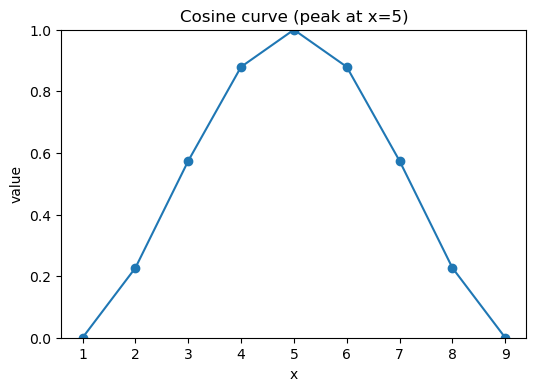

In [ ]:
# x from 1 to 9
x = np.arange(1, 10)
# cosine with peak centered at x=5
y_raw = np.cos(2 * np.pi * (x - 5) / 9)
# normalize to range 0 → 1
y = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())

plt.figure(figsize=(6, 4))
plt.plot(x,y,marker="o",)
plt.xticks(x)
plt.ylim(0, 1)
plt.xlabel("x")
plt.ylabel("value")
plt.title("Cosine curve (peak at x=5)")

plt.show()

In [14]:
synapse_count_table_add_bump = glucl.add_cosine_bump_columns(
    summary_df=synapse_count_table
)

synapse_count_table_add_bump.head()

,id,instance,total_input,axonal_input,dendritic_input,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,...,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,911911004,L1L9R8_R,724,101,623,0.0,22.894841,57.971773,88.817909,101.0,...,0.0,623.0,531.763762,311.5,91.236238,0.0,91.236238,311.5,531.763762,623.0
1,911919917,L1L9R8_R,554,98,456,0.0,22.214796,56.249839,86.179754,98.0,...,0.0,456.0,389.220346,228.0,66.779654,0.0,66.779654,228.0,389.220346,456.0
2,5813061383,L1L9R8_R,644,95,549,0.0,21.534752,54.527905,83.541598,95.0,...,0.0,549.0,468.600811,274.5,80.399189,0.0,80.399189,274.5,468.600811,549.0
3,911574261,L1L9R8_R,593,90,503,0.0,20.401344,51.658016,79.144672,90.0,...,0.0,503.0,429.337355,251.5,73.662645,0.0,73.662645,251.5,429.337355,503.0
4,881221166,L1L9R8_R,611,71,540,0.0,16.094393,40.752435,62.436352,71.0,...,0.0,540.0,460.918831,270.0,79.081169,0.0,79.081169,270.0,460.918831,540.0


In [28]:
bump_cols = [
    c
    for c in synapse_count_table_add_bump.columns
    if c.startswith("axon_") or c.startswith("dendrite_")]

synapse_count_table_add_bump_summary = pd.DataFrame([synapse_count_table_add_bump[bump_cols].sum()])

synapse_count_table_add_bump_summary.insert(
    0,
    "source",
    "no_glucl_weight_added",)

synapse_count_table_add_bump_summary

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.65589,2772.0,2437.65589,1591.066884,628.361387,0.0,21704.0,18525.522789,10852.0,3178.477211,0.0,3178.477211,10852.0,18525.522789,21704.0


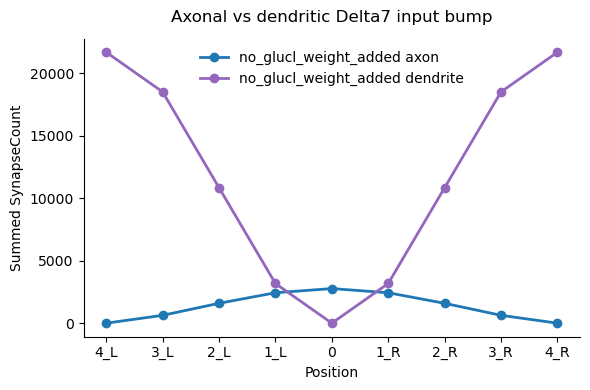

In [37]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary,
    title="Axonal vs dendritic Delta7 input bump",
    ylabel="Summed SynapseCount",
    axon_colors="tab:blue",
    dendrite_colors="tab:purple",
    figsize=(6, 4),
    # save_svg=results_dir / dataset_name / "Delta7_per_cell" / "axon_dendrite_bump_summary.svg",
)

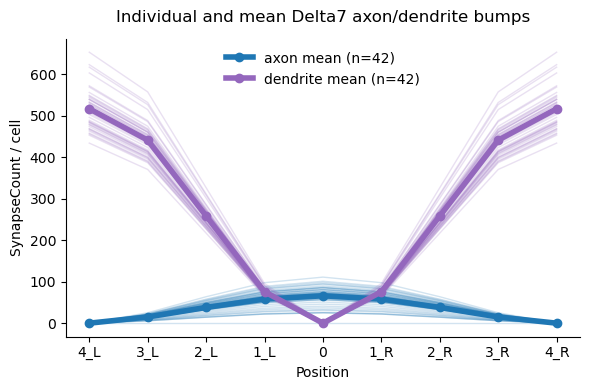

In [39]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump,
    sum_df=synapse_count_table_add_bump_summary,
    axon_color="tab:blue",
    dendrite_color="tab:purple",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

In [ ]:
# get the glucl scaling values for axonal inputs and dendritic inputs

glucl_scaling_values = glucl.compute_glucl_scaling_values(
    summary_df=summary_df,
    divide_by=24,)

glucl_scaling_values

{'percentage_total_green_dendritemean': 0.21254010709238122,
 'percentage_total_green_axon': 1.0,
 'percentage_total_green_divided_by_d7countall_dendritemean': 0.0057912990777446195,
 'percentage_total_green_divided_by_d7countall_axon': 0.023083264633140973}

In [ ]:
synapse_count_table_add_bump_summary_glucl = (
    glucl.build_multiplied_bump_summary(
        summary_df=summary_df,
        bump_summary_df=synapse_count_table_add_bump_summary,
        divide_by=24,
    ))

synapse_count_table_add_bump_summary_all = pd.concat(
    [
        synapse_count_table_add_bump_summary,
        synapse_count_table_add_bump_summary_glucl,
    ],
    ignore_index=True,)
synapse_count_table_add_bump_summary_all

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,21704.000000,18525.522789,10852.000000,3178.477211,0.0,3178.477211,10852.000000,18525.522789,21704.000000
1,multiply_percentage_total_green,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,4612.970484,3937.416598,2306.485242,675.553887,0.0,675.553887,2306.485242,3937.416598,4612.970484
2,multiply_percentage_total_green_divided_by_d7c...,0.0,14.504632,36.727018,56.269056,63.98681,56.269056,36.727018,14.504632,0.0,125.694355,107.286843,62.847178,18.407512,0.0,18.407512,62.847178,107.286843,125.694355


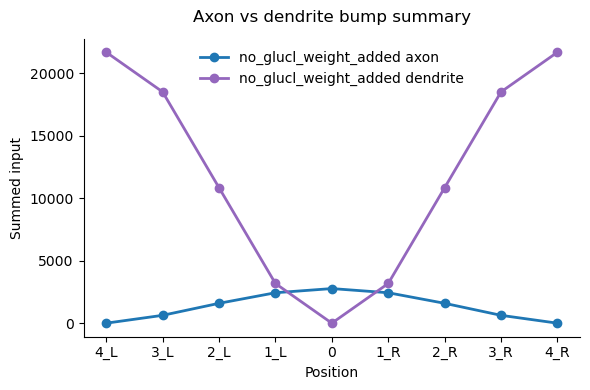

In [44]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=[0],
    axon_colors=["tab:blue"],
    dendrite_colors=["tab:purple"],
    figsize=(6, 4),
)

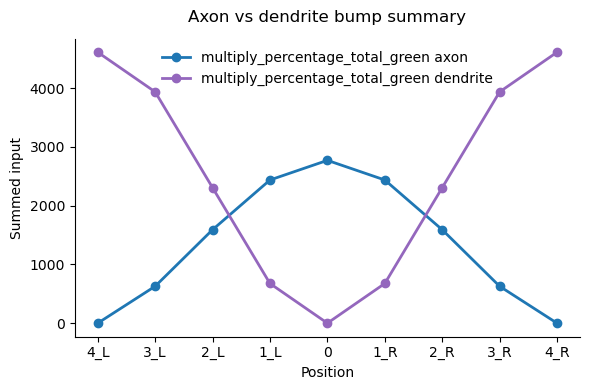

In [48]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=["multiply_percentage_total_green"],
    axon_colors="tab:blue",
    dendrite_colors="tab:purple",
    figsize=(6, 4),
)

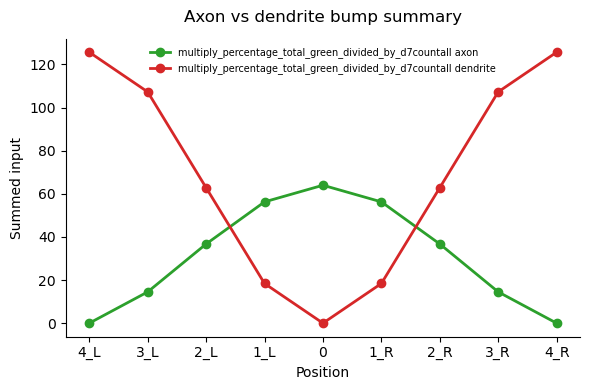

In [55]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=[2],
    axon_colors=["tab:green"],
    dendrite_colors=["tab:red"],
    figsize=(6, 4),
    legend_fontsize=7,
)

In [ ]:
row1 = synapse_count_table_add_bump_summary_all.loc[
    synapse_count_table_add_bump_summary_all["source"]
    == "multiply_percentage_total_green"
].iloc[0]

row2 = synapse_count_table_add_bump_summary_all.loc[
    synapse_count_table_add_bump_summary_all["source"]
    == "multiply_percentage_total_green_divided_by_d7countall"
].iloc[0]

numeric_cols = [
    c for c in synapse_count_table_add_bump_summary_all.columns
    if c != "source"
]

ratio = row2[numeric_cols] / row1[numeric_cols]
ratio

axon_4_L             NaN
axon_3_L        0.023083
axon_2_L        0.023083
axon_1_L        0.023083
axon_0          0.023083
axon_1_R        0.023083
axon_2_R        0.023083
axon_3_R        0.023083
axon_4_R             NaN
dendrite_4_L    0.027248
dendrite_3_L    0.027248
dendrite_2_L    0.027248
dendrite_1_L    0.027248
dendrite_0           NaN
dendrite_1_R    0.027248
dendrite_2_R    0.027248
dendrite_3_R    0.027248
dendrite_4_R    0.027248
dtype: object

# for each cell, don't combine axonal/dendritic inputs

In [72]:
d7_input_matrix = glucl.build_d7_input_matrix(
    delta_name=hemibrain_d7_names,   # or your demibrain_df_names
    input_dict=all_d7_per_cell,)

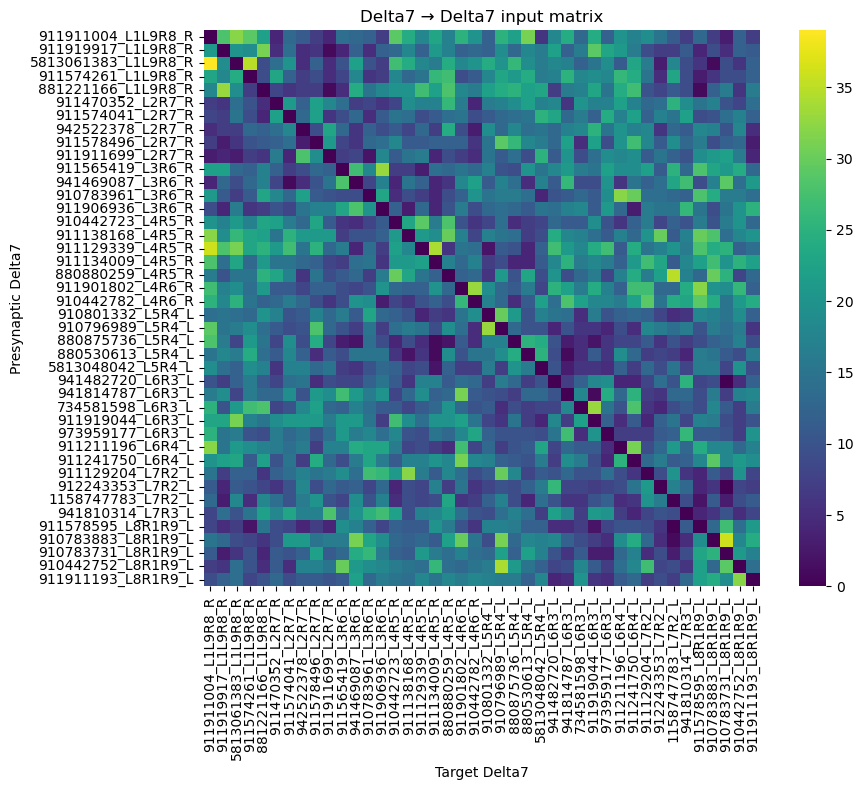

In [73]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    d7_input_matrix,
    cmap="viridis",
    square=True,)

plt.xlabel("Target Delta7")
plt.ylabel("Presynaptic Delta7")
plt.title("Delta7 → Delta7 input matrix")
plt.tight_layout()
plt.show()

In [ ]:
d7_relative_glomerulus_matrix = glucl.build_d7_relative_glomerulus_matrix(
    reference_matrix=d7_input_matrix,
    glomerulus_order=["L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"],)

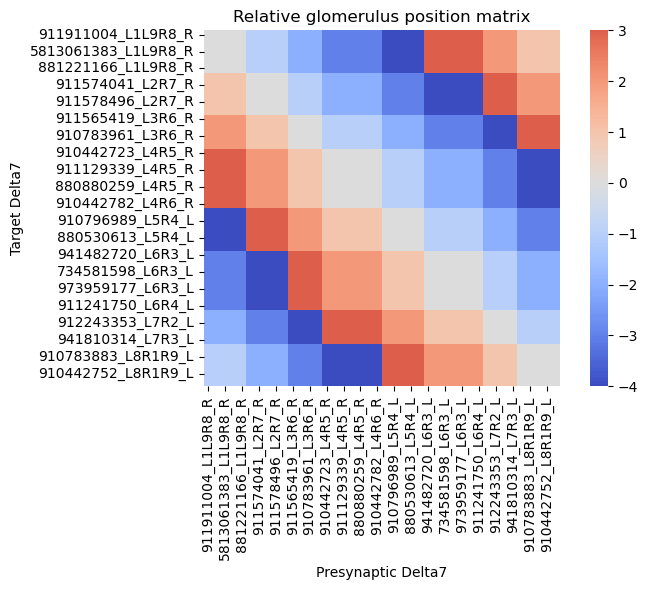

In [75]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

In [69]:
d7_glucl_matrix_percentage_total_green = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:853: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


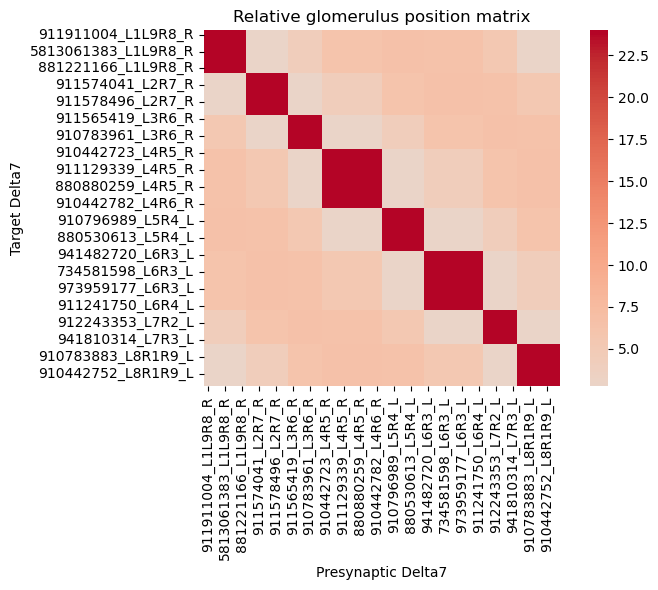

In [76]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_glucl_matrix_percentage_total_green,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

In [77]:
d7_glucl_matrix_d7norm = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green_divided_by_d7countall",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:853: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


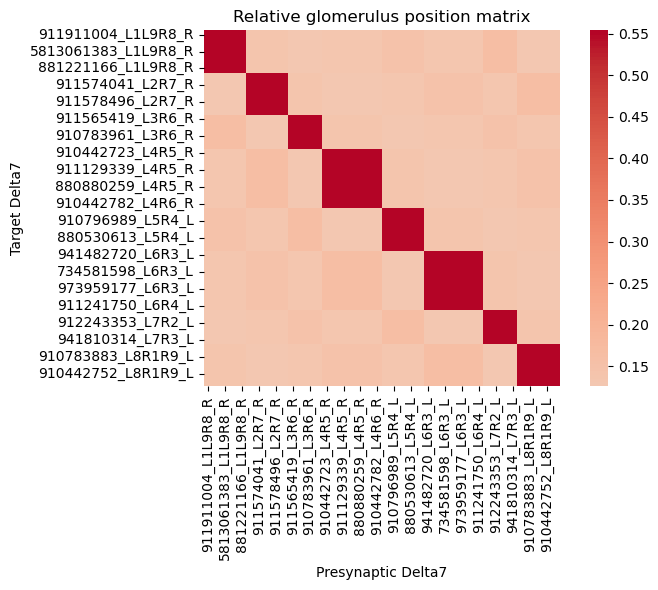

In [78]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_glucl_matrix_d7norm,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

In [67]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>